In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from quspin.operators import hamiltonian
from DSF import *

In [ ]:
N = 7
w = np.linspace(0.0, 8.0, 1601)
k_d = 120
N_samples = 10

basis, r = build_basis(N, "1")
H = H_BLBQ(N, 0.102*np.pi, basis, obc=True)
[E0] = H.eigsh(k=1, which="SA", maxiter=1e4, return_eigenvectors=False)
# psi_0 = psi_0.flatten()
print(E0)

S1_list = []
S2_list = []
# momentum space at k = Q
# Q = np.pi * 4/N
# for i in range(N):
#     S1_list.append([1/(N)**0.5 * np.exp(1j* Q*r[i]), i])
#     # S2_list.append([1/(N)**0.5 * np.exp(-1j* Q*r[i]), i])
#     S2_list.append([0, i])
# S2_list[3][0] = 1/(N)**0.5 * np.exp(-1j* Q*r[3])
# real space <Si Sj>
Si = 3
for i in range(N):
    S1_list.append([0, i])
    S2_list.append([0, i])
S1_list[Si][0] = 1
S2_list[Si][0] = 1

Sz1 = hamiltonian([["z", S1_list]], [], basis=basis, dtype=np.complex128, check_herm = False)
Sz2 = hamiltonian([["z", S2_list]], [], basis=basis, dtype=np.complex128, check_herm = False)

Szz, Z = dsf_lanczos(Sz1, Sz2, H, E0, k_d, N_samples, w, beta=[10/1])
# Szz_T0_L = dsf_lanczos_T0(Sz1, Sz2, H, E0, k_d, N_samples, w)
# Szz, Z = dsf_lanczos_src([Sz1], [Sz2], H, E0, psi_0, k_d, N_samples, w, beta=[10/1])

E_0, V_0, Szz_full, Z_full, Szz_full_T0 = dsf_exact(Sz1, Sz2, H, w, [10/1])


Hilbert space size: 2187.

Hermiticity check passed!
Symmetry checks passed!
-3.812975779874269
Symmetry checks passed!
Symmetry checks passed!
Time to finish lanczos basis 1: 4.377146482467651 sec
Time to finish lanczos basis 2: 4.32331919670105 sec
Time to finish lanczos basis 3: 7.7689595222473145 sec
Time to finish lanczos basis 4: 6.621033668518066 sec
Time to finish lanczos basis 5: 4.8707311153411865 sec
Time to finish lanczos basis 6: 3.6488256454467773 sec
Time to finish lanczos basis 7: 3.484567165374756 sec
Time to finish lanczos basis 8: 4.120427370071411 sec
Time to finish lanczos basis 9: 4.137645483016968 sec
Time to finish lanczos basis 10: 4.320683717727661 sec
E0 = -3.8129757798742725
Eigenenergy: [ 0.          0.          0.         ... 11.39747177 11.39747177
 11.39747177]
Peak memory used for exact solution w=0.0:908.1445 MB
Peak memory used for exact solution w=0.0:908.1445 MB
Peak memory used for exact solution w=0.0:908.1445 MB
Peak memory used for exact solutio

/home/amos1/miniconda3/envs/quspin/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/amos1/miniconda3/envs/quspin/lib/python3.10/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


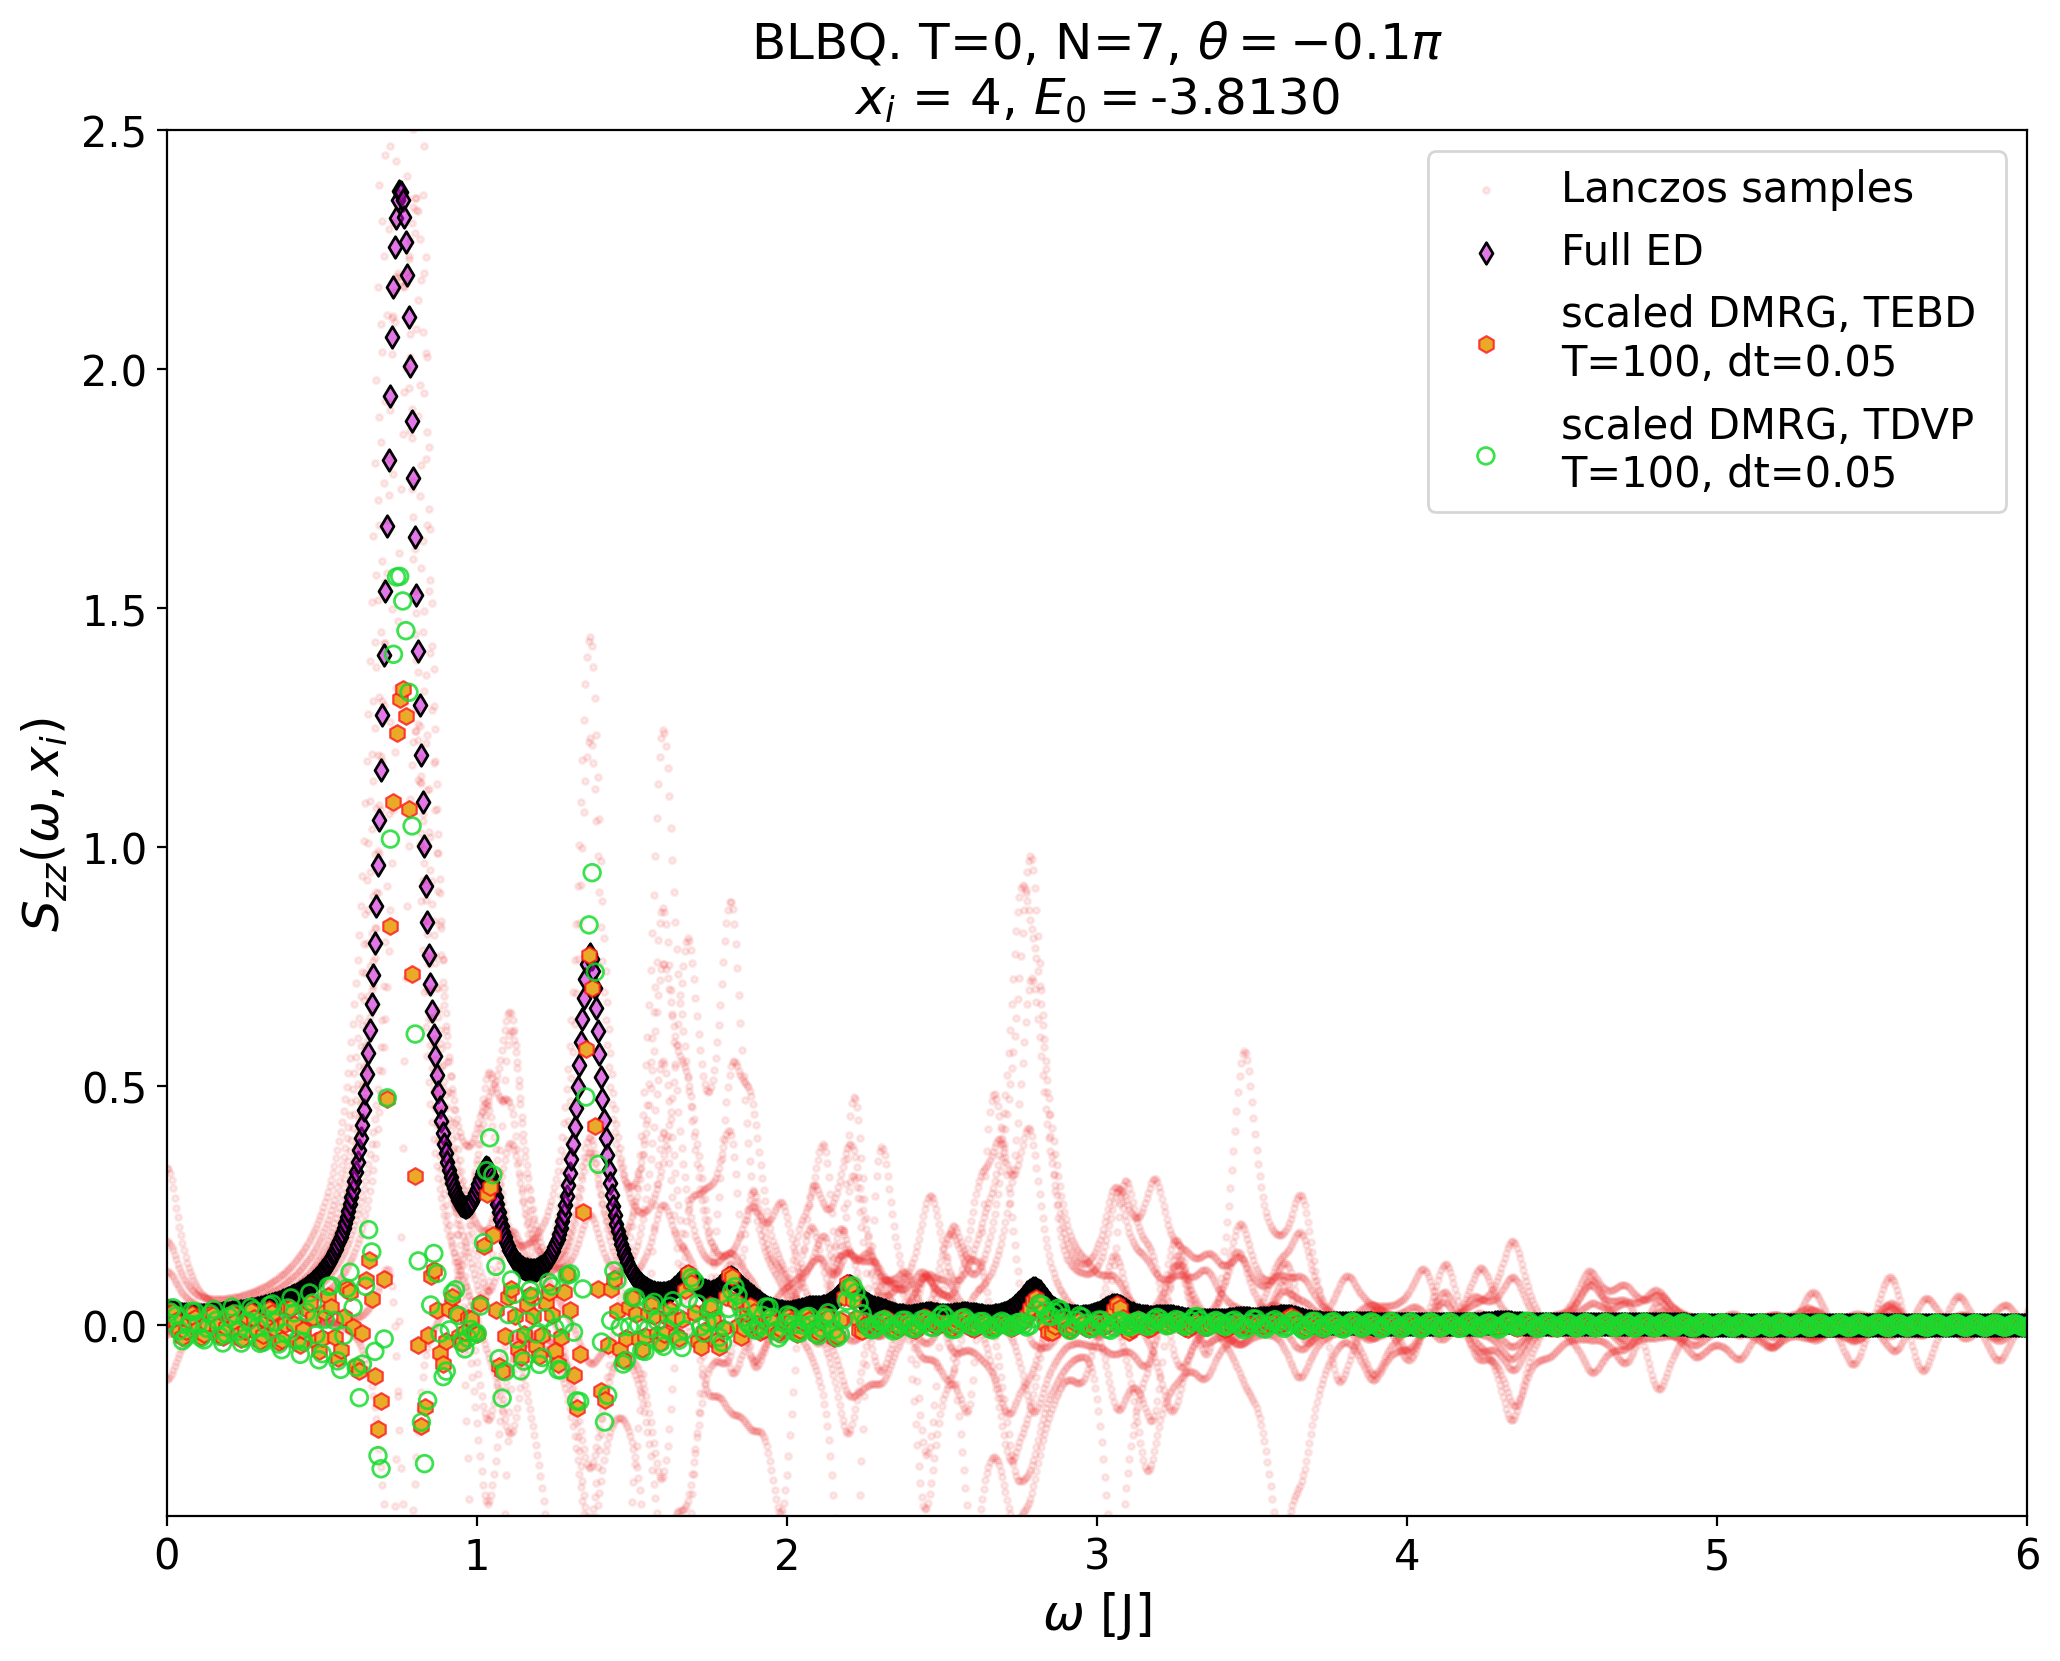

In [57]:
N = 7
theta = 0.102
k = 0.57
X = Si + 1
T = 100
tau = 0.05

# filename = (f"./BLBQ_data/S_N{N}_obc_theta{theta}0_k{k}_T{T}_dt{tau}_zz.csv")
filename = (f"./BLBQ_data/S_N{N}_obc_theta{theta}_x{X}_T{T}_dt{tau}_zz.csv")
spectra = pd.read_csv(filename)

# filename = (f"./BLBQ_data/S_N{N}_obc_theta{theta}0_k{k}_T{T}_dt{tau}_zz_TDVP.csv")
filename = (f"./BLBQ_data/S_N{N}_obc_theta{theta}_x{X}_T{T}_dt{tau}_zz_TDVP.csv")
spectra_tdvp = pd.read_csv(filename)

omega1 = np.linspace(0, 8, 800)
omega2 = np.linspace(0, 8, 1600)

fig, ax = plt.subplots(figsize=(12, 9), dpi=200)

for i in range(N_samples):
    if i == 0:
        label = "Lanczos samples"
    else: label = None
    ax.scatter(w, Szz[i]/Z[i],
        s=5, alpha=0.1, c="#F03333", label=label)
# ax.scatter(w, Szz[2]/Z[2], s=10, alpha=0.1, c="#25A6F6", label="Lanczos ED")

# ax.scatter(w, Szz_full.flatten()/Z_full, s=10, marker="d", alpha=0.5, c="#BF63D2", label="Full ED, T=0.1")

# for i in range(N_samples):
#     if i == 0:
#         label = "Lanczos samples"
#     else: label = None
#     ax.scatter(w, Szz_T0_L[i]*1000,
#         s=10, alpha=0.1, c="#F65225", label=label)

ax.scatter(w, Szz_full_T0.flatten(), 
    s=30, marker="d", c="#CC0FD690", edgecolors='k',
    label="Full ED")

# ax.scatter(w, a3, s=5, marker="h", alpha=0.2, c="#45F065", label="Mean")
ax.scatter(omega1, spectra["RS"]/30, 
    marker="h", c="#E9A929FF", edgecolors="#FF1418C8", linewidths=0.8, s=36, 
    label=f"scaled DMRG, TEBD \nT={T}, dt={tau}")

ax.scatter(omega1, spectra_tdvp["RS"]/30, 
    marker="o", c="None", edgecolors="#17DC2ED6", linewidths=1, s=36, 
    label=f"scaled DMRG, TDVP \nT={T}, dt={tau}")

ax.legend(fontsize=15)
ax.set_xlabel("$\\omega$ [J]", fontsize=18)
ax.set_ylabel("$S_{{zz}}(\\omega, x_i)$", fontsize=18)
ax.set_xlim(0, 6)
# ax.set_ylim(-0.2, 2.5)
ax.set_ylim(-0.4, 2.5)
ax.tick_params(axis='both', labelsize=15)

# ax.set_title("BLBQ. T=0, N={0:d}, k = {1:.2f}$\\pi$, $\\theta=-0.1\\pi$, $E_0=${2:.4f}".format(N, Q/(np.pi), E0), fontsize=18)
ax.set_title("BLBQ. T=0, N={0:d}, $\\theta=-0.1\\pi$ \n$x_i$ = {1:d}, $E_0=${2:.4f}".format(N, Si+1, E0), fontsize=18)

plt.show()

In [123]:
def bootstrap_mean(O_r, Id_r, n_bootstrap=100):
    """
    Uses boostraping to esimate the error due to sampling.

    O_r: numerator
    Id_r: denominator
    n_bootstrap: bootstrap sample size

    """
    O_r = np.asarray(O_r)
    Id_r = np.asarray(Id_r)
    #
    avg = np.nanmean(O_r, axis=0) / np.nanmean(Id_r, axis=0)
    n_Id = Id_r.shape[0]
    # n_N = O_r.shape[0]
    #
    i_iter = (np.random.randint(n_Id, size=n_Id) for i in range(n_bootstrap))
    #
    bootstrap_iter = (
        np.nanmean(O_r[i, ...], axis=0) / np.nanmean(Id_r[i, ...], axis=0)
        for i in i_iter
    )
    diff_iter = ((bootstrap - avg) ** 2 for bootstrap in bootstrap_iter)
    err = np.sqrt(sum(diff_iter) / n_bootstrap)
    #
    return avg, err

a3 = []
b3 = []

for i in range(len(w)):

    # calculating error bars on the expectation values
    # o3, do3 = bootstrap_mean(np.array(Szz)[:, i], Z)
    o3, do3 = bootstrap_mean(np.array(Szz_T0_L)[:, i], np.ones(10)/1000)

    a3.append(o3)
    b3.append(do3)
  

In [67]:
psi_i[0, :] @ psi_i[0, :]

np.complex128(1.0000000000000009+0j)

In [63]:
psi_0.conj() @ psi_0

np.complex128(0.9999999999999984+0j)

In [72]:
psi_0

array([-0.19686992+0.22421913j,  0.04282172+0.07462795j,
        0.04282172+0.07462795j, ...,  0.07029318-0.10017342j,
        0.07029318-0.10017342j,  0.21813808+0.30514166j], shape=(2048,))

In [17]:
psi_0.flatten()

array([-8.06927883e-18+2.99203700e-17j,  3.25213790e-19-1.14676361e-17j,
        1.03437849e-17-1.69968098e-18j, ...,
       -3.10608073e-18+1.02061529e-17j,  2.57488513e-18-4.76008395e-18j,
       -1.60639477e-17-1.94826796e-17j], shape=(2187,))

In [20]:
E_0

array([ 0.        ,  0.33745147,  0.33745147, ..., 18.40297693,
       18.40297693, 18.40297693], shape=(2187,))

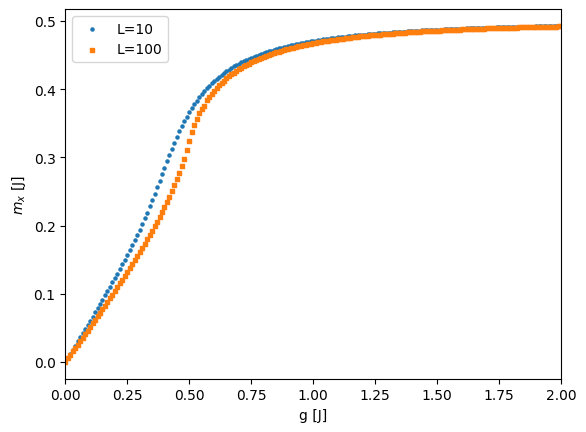

In [9]:
fig, ax = plt.subplots()

data10 = pd.read_csv("./N10_transfer.csv")
data100 = pd.read_csv("./N100_transfer.csv")

ax.scatter(data10.g, data10.mx, marker='o', label="L=10", s=5)
ax.scatter(data100.g, data100.mx, marker="s", label="L=100", s=5)

ax.legend()
ax.set_xlim(0, 2)
ax.set_xlabel("g [J]")
ax.set_ylabel("$m_x$ [J]")

plt.show()